In [1]:
!pip install -q -U diffusers transformers accelerate safetensors

In [2]:
import torch
from diffusers import StableDiffusionXLPipeline
from IPython.display import display
from google.colab import files

MODEL_ID = "stabilityai/stable-diffusion-xl-base-1.0"

pipe = StableDiffusionXLPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    use_safetensors=True
)

pipe = pipe.to("cuda")

print("Model loaded successfully!")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Model loaded successfully!


In [3]:
prompt = input("Enter your prompt: ")

print("\nGenerating image...")
print("Prompt:", prompt)

Enter your prompt: A breathtaking mountain landscape at sunrise, snow-covered mountains, crystal clear lake reflecting the sky, green pine forest, soft golden sunlight, morning mist, cinematic photography, photorealistic, highly detailed, 8K

Generating image...
Prompt: A breathtaking mountain landscape at sunrise, snow-covered mountains, crystal clear lake reflecting the sky, green pine forest, soft golden sunlight, morning mist, cinematic photography, photorealistic, highly detailed, 8K


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


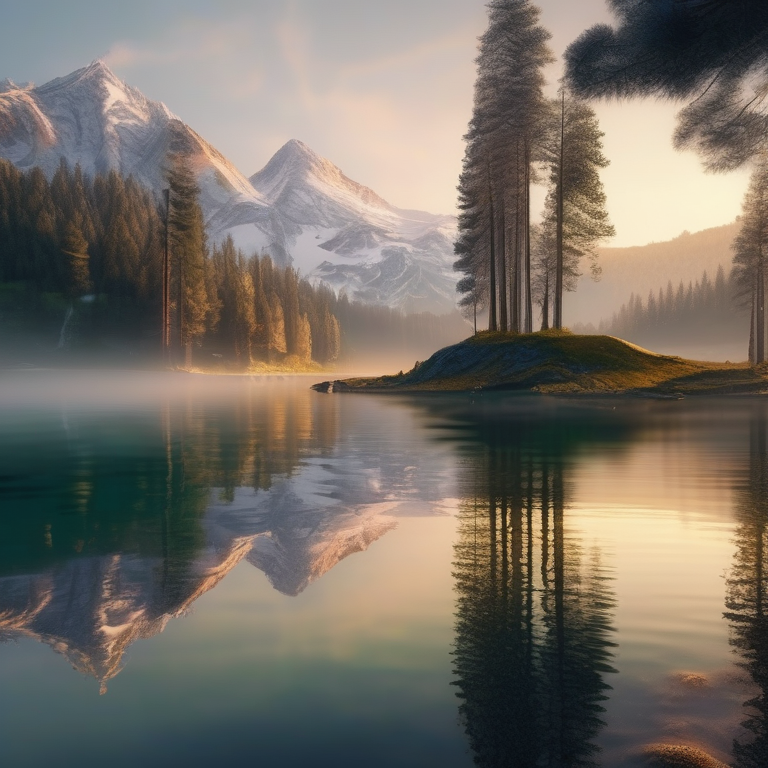

In [4]:
image = pipe(
    prompt=prompt,
    height=768,
    width=768,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

display(image)

In [5]:
output_path = "/content/generated_image.png"

image.save(output_path)

print("Image saved successfully!")

files.download(output_path)

Image saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
!pip install -q gradio

In [ ]:
import gradio as gr
import torch
import time


def generate_image(prompt, steps, guidance, width, height, seed):

    if not prompt.strip():
        return None, "Please enter a prompt."

    try:
        seed = int(seed)

        generator = torch.Generator(device="cuda").manual_seed(seed)

        start_time = time.time()

        image = pipe(
            prompt=prompt,
            height=int(height),
            width=int(width),
            num_inference_steps=int(steps),
            guidance_scale=float(guidance),
            generator=generator
        ).images[0]

        generation_time = time.time() - start_time

        info = (
            f"✅ Image generated successfully!\n\n"
            f"Seed: {seed}\n"
            f"Resolution: {width} × {height}\n"
            f"Steps: {steps}\n"
            f"Generation time: {generation_time:.2f} seconds"
        )

        return image, info

    except Exception as e:
        return None, f"❌ Error: {str(e)}"


with gr.Blocks(
    title="AI Image Generator"
) as demo:

    gr.Markdown(
        """
        # 🎨 AI Image Generator

        ### Generate images using Stable Diffusion XL

        Enter a text prompt and let the AI create your image.
        """
    )

    with gr.Row():

        # -----------------------------
        # LEFT SIDE
        # -----------------------------

        with gr.Column(scale=1):

            prompt = gr.Textbox(
                label="✨ Enter Your Prompt",
                placeholder=(
                    "Example: A futuristic AI laboratory "
                    "with humanoid robots..."
                ),
                lines=6
            )

            generate_button = gr.Button(
                "🚀 Generate Image",
                variant="primary"
            )

            gr.Markdown("### ⚙️ Generation Settings")

            steps = gr.Slider(
                minimum=10,
                maximum=50,
                value=30,
                step=1,
                label="Inference Steps"
            )

            guidance = gr.Slider(
                minimum=1,
                maximum=15,
                value=7.5,
                step=0.5,
                label="Guidance Scale"
            )

            width = gr.Dropdown(
                choices=[512, 768, 1024],
                value=768,
                label="Width"
            )

            height = gr.Dropdown(
                choices=[512, 768, 1024],
                value=768,
                label="Height"
            )

            seed = gr.Number(
                value=42,
                precision=0,
                label="Seed"
            )


        # -----------------------------
        # RIGHT SIDE
        # -----------------------------

        with gr.Column(scale=1):

            output_image = gr.Image(
                label="🖼️ Generated Image",
                type="pil"
            )

            output_info = gr.Textbox(
                label="Generation Information",
                lines=7
            )


    # -----------------------------
    # BUTTON EVENT
    # -----------------------------

    generate_button.click(
        fn=generate_image,
        inputs=[
            prompt,
            steps,
            guidance,
            width,
            height,
            seed
        ],
        outputs=[
            output_image,
            output_info
        ]
    )


demo.launch(
    share=True,
    debug=True
)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://97c663c927b7ec4cff.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
